# Aprendizaje Automático
# Trabajo Práctico 2

Profesor: Juan Luis Crespo Mariño

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---

Fecha de entrega: 11 de agosto, hora límite las 6:00 pm.

Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

BD utilizada: https://archive.ics.uci.edu/dataset/2/adult


Estudiante:
1. **Jose Pablo Ruiz Myrie**
2. **Nikole Villalobos Lopez**


# Notebook 04 — Modelo Random Forest

En este notebook se entrena y evalúa un clasificador Random Forest para
determinar si el ingreso anual de una persona supera los $50K. Se utiliza el
dataset `datos_finales.csv`, que ya contiene las variables seleccionadas,
imputadas, codificadas y escaladas en los notebooks anteriores, incluyendo el
tratamiento de outliers (transformación logarítmica de `capital-gain` y
`capital-loss`).

El notebook amplía las pruebas de Random Forest para comparar de forma
consistente distintas combinaciones de hiperparámetros. Además incluye:

- un **experimento con distintas codificaciones** (One-Hot vs Ordinal) para
  verificar su efecto sobre el rendimiento;
- la **evaluación final** del modelo seleccionado sobre el conjunto de prueba;
- el **reentrenamiento con el 100% de los datos** y el guardado del modelo.

El objetivo principal de este modelo es mejorar la **Accuracy** y la
**Precision**, por lo que la selección final priorizará estas métricas.

### División de los datos

El dataset se divide en tres conjuntos: 70% entrenamiento, 15% validación y 15% prueba. Esta distribución permite disponer de suficientes observaciones para entrenar y, al mismo tiempo, mantener conjuntos independientes para seleccionar y evaluar la mejor configuración.

- **Entrenamiento (70%):** para ajustar el Random Forest en sus distintas configuraciones de hiperparámetros.
- **Validación (15%):** para comparar las combinaciones de hiperparámetros y seleccionar la de mejor desempeño.
- **Prueba (15%):** se utiliza únicamente al final para evaluar el modelo ganador sobre datos no vistos.

### Diseño del estudio de hiperparámetros

Random Forest es un modelo de ensamble que combina múltiples árboles de decisión entrenados sobre muestras y subconjuntos de variables distintos. Esto reduce la varianza y suele mejorar la generalización frente a un único árbol. Se prueban 12 configuraciones que modifican de forma controlada:

- la cantidad de árboles (`n_estimators`);
- la profundidad máxima (`max_depth`);
- el mínimo de muestras para dividir un nodo (`min_samples_split`);
- el mínimo de muestras por hoja (`min_samples_leaf`);
- la cantidad de variables consideradas por división (`max_features`);
- el balanceo de clases (`class_weight`);
- el criterio de división (`gini` vs `entropy`).

Algunas configuraciones buscan mayor generalización y otras favorecen la clase positiva `>50K`. Para evaluar el desempeño se usan accuracy, precision, recall, F1 y AUC-ROC, métricas en las que un valor mayor indica un mejor resultado. El conjunto de prueba se reserva para la evaluación final.

In [1]:
# ============================================================
# Preparación de los datos e importe de librerías
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# -----------------------------------------------------------
# 1. Cargamos los datos
# -----------------------------------------------------------

# Usamos datos_finales.csv, que ya incluye el preprocesado completo
# (imputación, tratamiento de outliers, codificación y escalado)
df = pd.read_csv("../data/datos_finales.csv")

print("Dimensiones del dataset:")
print(df.shape)
df.head()

Dimensiones del dataset:
(48842, 82)


,age,education-num,capital-gain-log,capital-loss-log,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,-0.119879,1.136512,-0.297918,-0.221264,-2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,1.265933,-0.808297,-0.297918,4.450068,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.047121,-0.419335,-0.297918,-0.221264,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,2.432933,-1.197259,-0.297918,-0.221264,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.536558,1.525474,-0.297918,-0.221264,-0.4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [3]:
# -----------------------------------------------------------
# 2. Separamos variables predictoras y variable objetivo
# -----------------------------------------------------------

# El archivo datos_finales ya contiene las variables predictoras
# imputadas, codificadas y escaladas
X_model = df.drop(columns=["income"])

# La variable objetivo ya se encuentra codificada como 0 = <=50K y 1 = >50K
y_model = df["income"]


# -----------------------------------------------------------
# 3. Separación de entrenamiento, validación y prueba
# -----------------------------------------------------------

# Separamos en 70% entrenamiento y 30% temporal para validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42,
    stratify=y_model
)

# Dividimos el 30% temporal en 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (34189, 81)
Val  : (7326, 81)
Test : (7327, 81)


## Configuraciones de Random Forest

Se definen 12 configuraciones de hiperparámetros. La primera funciona como modelo base y las siguientes modifican distintos aspectos (número de árboles, profundidad, regularización, `max_features`, balanceo de clases y criterio) para analizar su efecto sobre el rendimiento.

In [4]:
# -----------------------------------------------------------
# 4. Definición de las 12 configuraciones de hiperparámetros
# -----------------------------------------------------------

rf_configurations = {
    "RF 01 - Baseline": {
        "n_estimators": 200, "max_depth": None, "min_samples_split": 2,
        "min_samples_leaf": 1, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 02 - Mas arboles": {
        "n_estimators": 500, "max_depth": None, "min_samples_split": 2,
        "min_samples_leaf": 1, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 03 - Depth 12": {
        "n_estimators": 400, "max_depth": 12, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 04 - Depth 16": {
        "n_estimators": 400, "max_depth": 16, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 05 - Depth 20": {
        "n_estimators": 400, "max_depth": 20, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 06 - Regularizado": {
        "n_estimators": 400, "max_depth": 14, "min_samples_split": 10,
        "min_samples_leaf": 4, "max_features": "sqrt", "class_weight": None,
        "criterion": "gini"
    },
    "RF 07 - MaxFeatures 0.5": {
        "n_estimators": 400, "max_depth": 18, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": 0.5, "class_weight": None,
        "criterion": "gini"
    },
    "RF 08 - MaxFeatures 0.7": {
        "n_estimators": 400, "max_depth": 18, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": 0.7, "class_weight": None,
        "criterion": "gini"
    },
    "RF 09 - Balanced": {
        "n_estimators": 400, "max_depth": 16, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": "balanced",
        "criterion": "gini"
    },
    "RF 10 - Balanced subsample": {
        "n_estimators": 500, "max_depth": 18, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt",
        "class_weight": "balanced_subsample", "criterion": "gini"
    },
    "RF 11 - Precision focus": {
        "n_estimators": 500, "max_depth": 20, "min_samples_split": 8,
        "min_samples_leaf": 3, "max_features": 0.7, "class_weight": None,
        "criterion": "gini"
    },
    "RF 12 - Entropy": {
        "n_estimators": 500, "max_depth": 18, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": None,
        "criterion": "entropy"
    }
}

print("Cantidad de configuraciones:", len(rf_configurations))

Cantidad de configuraciones: 12


In [5]:
# -----------------------------------------------------------
# 5. Entrenamiento de todas las configuraciones
# -----------------------------------------------------------

# Entrenamos cada configuración sobre el conjunto de entrenamiento y la
# evaluamos sobre validación. Guardamos los modelos y sus métricas.
rf_models = {}
rf_results = []

for model_name, params in rf_configurations.items():

    rf_model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    # Entrenamiento
    rf_model.fit(X_train, y_train)
    rf_models[model_name] = rf_model

    # Predicciones sobre validación
    y_pred = rf_model.predict(X_val)
    y_prob = rf_model.predict_proba(X_val)[:, 1]

    rf_results.append({
        "Modelo": model_name,
        "n_estimators": params["n_estimators"],
        "max_depth": str(params["max_depth"]),
        "max_features": str(params["max_features"]),
        "class_weight": str(params["class_weight"]),
        "criterion": params["criterion"],
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1": f1_score(y_val, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_val, y_prob)
    })

print("Todos los Random Forest fueron entrenados.")

Todos los Random Forest fueron entrenados.


In [6]:
# -----------------------------------------------------------
# 6. Comparación de resultados (conjunto de validación)
# -----------------------------------------------------------

rf_results_df = pd.DataFrame(rf_results)
metric_columns = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

print("COMPARACIÓN GENERAL DE RANDOM FOREST (validación)")
display(
    rf_results_df
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
    .style.format({m: "{:.4f}" for m in metric_columns})
)

# Mejor modelo según cada métrica
print("\nMejor modelo según cada métrica:")
for metric in metric_columns:
    best_index = rf_results_df[metric].idxmax()
    best_name = rf_results_df.loc[best_index, "Modelo"]
    best_value = rf_results_df.loc[best_index, metric]
    print(f"{metric:10s}: {best_name} -> {best_value:.4f}")

# El modelo con mayor F1 en validación (referencia del estudio)
best_rf_name = rf_results_df.loc[rf_results_df["F1"].idxmax(), "Modelo"]
best_rf_model = rf_models[best_rf_name]
print("\nModelo con mayor F1 en validación:")
print(best_rf_name)

COMPARACIÓN GENERAL DE RANDOM FOREST (validación)


,Modelo,n_estimators,max_depth,max_features,class_weight,criterion,Accuracy,Precision,Recall,F1,AUC-ROC
0,RF 10 - Balanced subsample,500,18,sqrt,balanced_subsample,gini,0.8182,0.5808,0.8631,0.6944,0.9173
1,RF 09 - Balanced,400,16,sqrt,balanced,gini,0.8145,0.5745,0.8671,0.6911,0.9165
2,RF 07 - MaxFeatures 0.5,400,18,0.5,None,gini,0.8625,0.7699,0.6070,0.6788,0.9161
3,RF 11 - Precision focus,500,20,0.7,None,gini,0.8608,0.7639,0.6052,0.6754,0.9147
4,RF 05 - Depth 20,400,20,sqrt,None,gini,0.8624,0.7799,0.5921,0.6732,0.9183
5,RF 08 - MaxFeatures 0.7,400,18,0.7,None,gini,0.8595,0.7631,0.5990,0.6711,0.9155
6,RF 04 - Depth 16,400,16,sqrt,None,gini,0.8619,0.7906,0.5750,0.6658,0.9171
7,RF 12 - Entropy,500,18,sqrt,None,entropy,0.8609,0.7841,0.5779,0.6654,0.9178
8,RF 06 - Regularizado,400,14,sqrt,None,gini,0.8595,0.7934,0.5585,0.6555,0.9150
9,RF 02 - Mas arboles,500,None,sqrt,None,gini,0.8441,0.6960,0.6189,0.6552,0.8919



Mejor modelo según cada métrica:
Accuracy  : RF 07 - MaxFeatures 0.5 -> 0.8625
Precision : RF 06 - Regularizado -> 0.7934
Recall    : RF 09 - Balanced -> 0.8671
F1        : RF 10 - Balanced subsample -> 0.6944
AUC-ROC   : RF 05 - Depth 20 -> 0.9183

Modelo con mayor F1 en validación:
RF 10 - Balanced subsample


El modelo con mayor F1 en validación es **RF 10 - Balanced subsample**, pero al usar balanceo de clases logra ese F1 a costa de una precision baja (muchos falsos positivos). Como el objetivo de este modelo es mejorar accuracy y precision, primero revisamos el desempeño de esta configuración sobre la prueba y luego evaluamos alternativas (incluido el experimento de codificación) antes de decidir el modelo final.

Desempeño en prueba de RF 10 - Balanced subsample:
Accuracy: 0.8166
Precision: 0.5780
Recall: 0.8642
F1: 0.6927
AUC-ROC: 0.9195


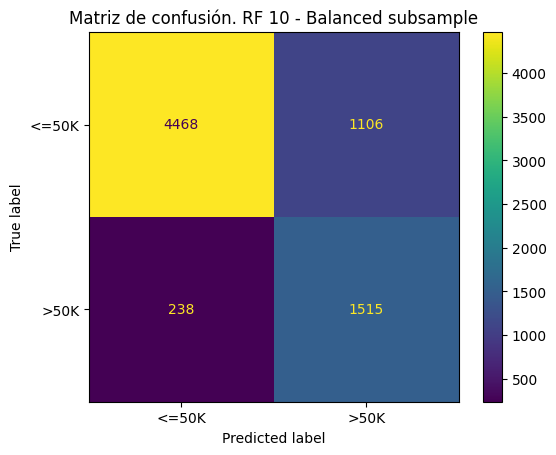

In [7]:
# -----------------------------------------------------------
# 7. Desempeño de la configuración con mayor F1 (referencia)
# -----------------------------------------------------------

y_pred_rf_test = best_rf_model.predict(X_test)
y_prob_rf_test = best_rf_model.predict_proba(X_test)[:, 1]

rf_test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf_test),
    "Precision": precision_score(y_test, y_pred_rf_test, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_test, zero_division=0),
    "F1": f1_score(y_test, y_pred_rf_test, zero_division=0),
    "AUC-ROC": roc_auc_score(y_test, y_prob_rf_test)
}

print(f"Desempeño en prueba de {best_rf_name}:")
for metric, value in rf_test_metrics.items():
    print(f"{metric}: {value:.4f}")

matriz_confusion_rf = confusion_matrix(y_test, y_pred_rf_test)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_rf,
    display_labels=["<=50K", ">50K"]
)
disp.plot()
plt.title(f"Matriz de confusión. {best_rf_name}")
plt.show()

## Experimento con distintas codificaciones

El dataset `datos_finales.csv` ya está codificado mediante One-Hot Encoding, por lo que para comparar codificaciones se utiliza `datos_procesados.csv`, que conserva las variables categóricas en su forma original (junto con el tratamiento de outliers ya aplicado).

Se comparan dos codificaciones para las variables categóricas manteniendo el mismo Random Forest:

- **One-Hot Encoding:** crea una columna binaria por cada categoría. No impone un orden entre categorías, pero aumenta la dimensionalidad.
- **Ordinal Encoding:** asigna un número entero a cada categoría. Mantiene baja la dimensionalidad; en modelos de árboles suele funcionar bien porque los cortes pueden separar grupos de categorías aunque el orden asignado sea arbitrario.

El objetivo es verificar si la codificación afecta el rendimiento del modelo.

In [8]:
# -----------------------------------------------------------
# 8. Comparación de codificaciones (One-Hot vs Ordinal)
# -----------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Cargamos los datos procesados (categóricas sin codificar)
df_proc = pd.read_csv("../data/datos_procesados.csv")

# La variable objetivo se codifica como 0 = <=50K y 1 = >50K
df_proc["income"] = (
    df_proc["income"].astype(str).str.strip().str.rstrip(".").map({"<=50K": 0, ">50K": 1})
)

numeric_columns = ["age", "education-num", "capital-gain-log", "capital-loss-log", "hours-per-week"]
categorical_columns = ["workclass", "marital-status", "occupation", "relationship", "race"]

X_enc = df_proc[numeric_columns + categorical_columns]
y_enc = df_proc["income"]

# Usamos una partición 80/20 con la misma semilla para comparar de forma justa
X_enc_train, X_enc_test, y_enc_train, y_enc_test = train_test_split(
    X_enc, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

# Definimos las dos codificaciones a comparar
encoders = {
    "One-Hot Encoding": OneHotEncoder(handle_unknown="ignore"),
    "Ordinal Encoding": OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
}

encoding_results = []
# Guardamos también los pipelines entrenados para poder reutilizar el ganador
encoding_pipelines = {}

for enc_name, encoder in encoders.items():

    preprocessor = ColumnTransformer(transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_columns),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", encoder)
        ]), categorical_columns)
    ])

    # Mismo Random Forest para ambas codificaciones
    encoding_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=400, max_depth=16, min_samples_split=5,
            min_samples_leaf=2, random_state=42, n_jobs=-1
        ))
    ])

    encoding_pipeline.fit(X_enc_train, y_enc_train)
    encoding_pipelines[enc_name] = encoding_pipeline

    y_pred = encoding_pipeline.predict(X_enc_test)
    y_prob = encoding_pipeline.predict_proba(X_enc_test)[:, 1]

    encoding_results.append({
        "Codificación": enc_name,
        "Accuracy": accuracy_score(y_enc_test, y_pred),
        "Precision": precision_score(y_enc_test, y_pred, zero_division=0),
        "Recall": recall_score(y_enc_test, y_pred, zero_division=0),
        "F1": f1_score(y_enc_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_enc_test, y_prob)
    })

encoding_results_df = pd.DataFrame(encoding_results)
print("Comparación de codificaciones:")
display(encoding_results_df.style.format({m: "{:.4f}" for m in metric_columns}))

Comparación de codificaciones:


,Codificación,Accuracy,Precision,Recall,F1,AUC-ROC
0,One-Hot Encoding,0.8621,0.7833,0.5860,0.6704,0.9191
1,Ordinal Encoding,0.8637,0.7746,0.6069,0.6806,0.9195


In [9]:
# -----------------------------------------------------------
# 9. Cómo quedaron codificadas las variables con Ordinal Encoding
# -----------------------------------------------------------

# OrdinalEncoder asigna a cada categoría un número entero según el orden
# alfabético de las categorías vistas en entrenamiento. Mostramos el mapeo
# resultante para cada variable categórica.
ordinal_encoder = (
    encoding_pipelines["Ordinal Encoding"]
    .named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)

for columna, categorias in zip(categorical_columns, ordinal_encoder.categories_):
    mapeo = {categoria: entero for entero, categoria in enumerate(categorias)}
    print(f"{columna}:")
    print("   ", mapeo)

workclass:
    {'Federal-gov': 0, 'Local-gov': 1, 'Never-worked': 2, 'Private': 3, 'Self-emp-inc': 4, 'Self-emp-not-inc': 5, 'State-gov': 6, 'Without-pay': 7}
marital-status:
    {'Divorced': 0, 'Married-AF-spouse': 1, 'Married-civ-spouse': 2, 'Married-spouse-absent': 3, 'Never-married': 4, 'Separated': 5, 'Widowed': 6}
occupation:
    {'Adm-clerical': 0, 'Armed-Forces': 1, 'Craft-repair': 2, 'Exec-managerial': 3, 'Farming-fishing': 4, 'Handlers-cleaners': 5, 'Machine-op-inspct': 6, 'Other-service': 7, 'Priv-house-serv': 8, 'Prof-specialty': 9, 'Protective-serv': 10, 'Sales': 11, 'Tech-support': 12, 'Transport-moving': 13}
relationship:
    {'Husband': 0, 'Not-in-family': 1, 'Other-relative': 2, 'Own-child': 3, 'Unmarried': 4, 'Wife': 5}
race:
    {'Amer-Indian-Eskimo': 0, 'Asian-Pac-Islander': 1, 'Black': 2, 'Other': 3, 'White': 4}


### Cómo se codificaron las variables con Ordinal Encoding y si tiene sentido

El `OrdinalEncoder` reemplaza cada categoría por un número entero. La correspondencia se asigna según el **orden alfabético** de las categorías observadas en el entrenamiento, empezando en 0. Por ejemplo, para `relationship` el mapeo es: `Husband=0, Not-in-family=1, Other-relative=2, Own-child=3, Unmarried=4, Wife=5`. Así, cada variable categórica pasa a ser **una sola columna numérica** (en lugar de muchas columnas binarias como en One-Hot). Las categorías no vistas en entrenamiento se codifican como `-1` gracias a `handle_unknown="use_encoded_value"`.

**¿Tiene sentido usar Ordinal Encoding aquí?** Sí, porque el modelo es un Random Forest (basado en árboles). Los árboles toman decisiones mediante cortes del tipo *"valor ≤ umbral"*, por lo que el número asignado funciona únicamente como una etiqueta que el árbol puede separar; el orden concreto (aunque sea arbitrario y no represente una jerarquía real, por ejemplo que `Wife=5` sea "mayor" que `Husband=0`) no engaña al modelo, ya que con suficientes cortes y árboles puede aislar cualquier categoría. Además reduce mucho la dimensionalidad.

Es importante notar que esto **solo es válido para modelos de árboles**. En modelos lineales (Regresión Logística) o basados en distancias (KNN), el Ordinal Encoding sería inadecuado porque interpretaría esos enteros como magnitudes con orden real, introduciendo relaciones falsas; por eso el resto del proyecto usa One-Hot en `datos_finales.csv`.

## Selección del modelo final

El experimento de codificación muestra que, con el mismo Random Forest y sin balanceo de clases, el **Ordinal Encoding** obtiene la mejor combinación de accuracy y precision (Accuracy ≈ 0.864, Precision ≈ 0.775), mejorando de forma notable la precision respecto a la configuración con mayor F1 (RF 10 - Balanced subsample, Precision ≈ 0.576) y sacrificando solo alrededor de 1 punto de F1.

Como el objetivo de este modelo es **mejorar Accuracy y Precision**, se selecciona el Random Forest con **Ordinal Encoding** como modelo final. El costo de esta decisión es un **recall menor** (identifica una menor proporción de la clase >50K), lo cual es aceptable dado el objetivo planteado.

EVALUACIÓN FINAL - Random Forest con Ordinal Encoding
Accuracy: 0.8637
Precision: 0.7746
Recall: 0.6069
F1: 0.6806
AUC-ROC: 0.9195


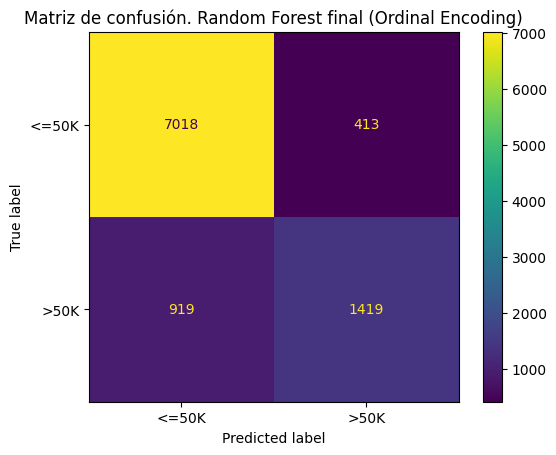

In [10]:
# -----------------------------------------------------------
# 10. Evaluación final del modelo seleccionado (Ordinal Encoding)
# -----------------------------------------------------------

final_model_name = "Ordinal Encoding"
final_random_forest = encoding_pipelines[final_model_name]

# Evaluación sobre el conjunto de prueba (partición 80/20 del experimento)
y_pred_final = final_random_forest.predict(X_enc_test)
y_prob_final = final_random_forest.predict_proba(X_enc_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_enc_test, y_pred_final),
    "Precision": precision_score(y_enc_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_enc_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_enc_test, y_pred_final, zero_division=0),
    "AUC-ROC": roc_auc_score(y_enc_test, y_prob_final)
}

print("EVALUACIÓN FINAL - Random Forest con Ordinal Encoding")
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

# Matriz de confusión del modelo final
matriz_confusion_final = confusion_matrix(y_enc_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_final,
    display_labels=["<=50K", ">50K"]
)
disp.plot()
plt.title("Matriz de confusión. Random Forest final (Ordinal Encoding)")
plt.show()

In [11]:
# -----------------------------------------------------------
# 11. Importancia de variables del modelo final
# -----------------------------------------------------------

# Como el modelo final usa Ordinal Encoding, cada variable categórica es una
# sola columna, por lo que las importancias son directamente interpretables.
importancias = pd.DataFrame({
    "Variable": numeric_columns + categorical_columns,
    "Importancia": final_random_forest.named_steps["classifier"].feature_importances_
}).sort_values("Importancia", ascending=False)

display(importancias.reset_index(drop=True))

,Variable,Importancia
0,capital-gain-log,0.199392
1,relationship,0.192981
2,education-num,0.172300
3,marital-status,0.109596
4,age,0.105847
5,hours-per-week,0.072279
6,capital-loss-log,0.057119
7,occupation,0.054616
8,workclass,0.026591
9,race,0.009281


### Análisis de resultados del modelo seleccionado como ganador

El estudio de hiperparámetros mostró que la configuración con mayor F1 en validación fue RF 10 - Balanced subsample, pero esa ganancia de F1 se apoya en un recall muy alto a costa de una precision baja (≈ 0.58 en prueba), lo que no se alinea con el objetivo de mejorar accuracy y precision. Por ello se evaluó el experimento de codificación, en el que el Random Forest con **Ordinal Encoding** (sin balanceo de clases) resultó la mejor alternativa para dicho objetivo.

El modelo final (Random Forest con Ordinal Encoding) obtuvo sobre el conjunto de prueba una exactitud de 86.37%, una precision de 77.46%, un recall de 60.69%, un F1 de 0.6806 y un AUC-ROC de 0.9195. En comparación con RF 10 - Balanced subsample (Accuracy 0.8156, Precision 0.5764, Recall 0.8648, F1 0.6918), el modelo final mejora la accuracy en unos 5 puntos y la precision en cerca de 20 puntos, sacrificando aproximadamente 1 punto de F1. La contraparte es una caída del recall (de 0.86 a 0.61), es decir, identifica una menor proporción de las personas con ingresos >50K, pero cuando predice >50K acierta con mucha mayor frecuencia.

En la matriz de confusión del modelo final se clasificaron correctamente 7018 individuos con ingresos iguales o inferiores a $50K y 1419 individuos con ingresos superiores a $50K. Se registraron 413 falsos positivos (personas clasificadas como >50K cuando eran <=50K) y 919 falsos negativos (personas clasificadas como <=50K cuando eran >50K). La reducida cantidad de falsos positivos es justamente lo que produce la alta precision buscada.

Respecto a las codificaciones, One-Hot y Ordinal ofrecieron resultados muy similares, lo que confirma que Random Forest es robusto frente a la forma de codificar las variables categóricas.

**Sobre el uso de Ordinal Encoding en variables nominales.** Es importante aclarar una duda válida: nuestras variables categóricas (`workclass`, `marital-status`, `occupation`, `relationship`, `race`) son **nominales**, es decir, no tienen un orden natural, y el Ordinal Encoding normalmente se asocia a variables ordinales. Sin embargo, funciona correctamente en este caso por dos razones. Primero, el nombre `OrdinalEncoder` en scikit-learn se refiere únicamente al formato de salida (convertir categorías a enteros) y no impone que la variable sea ordinal. Segundo, y más importante, el modelo es un **Random Forest (basado en árboles)**: los árboles solo realizan cortes del tipo `valor ≤ umbral`, por lo que el entero asignado actúa como una simple etiqueta separable y el orden arbitrario (por ejemplo `Wife=5` frente a `Husband=0`) no introduce una relación de magnitud u orden falsa. Con suficientes cortes y árboles, el bosque puede aislar cualquier categoría.

La única limitación es que un corte individual solo separa rangos contiguos del orden arbitrario, por lo que aislar una categoría concreta puede requerir varios cortes; en la práctica esto casi no afecta al Random Forest, como confirman los resultados casi idénticos frente a One-Hot. Cabe destacar que esta codificación **no sería adecuada en modelos lineales (Regresión Logística) ni basados en distancias (KNN)**, porque interpretarían esos enteros como magnitudes ordenadas y generarían relaciones inexistentes; por ese motivo el resto del proyecto conserva One-Hot en `datos_finales.csv`. Una alternativa que respeta explícitamente la naturaleza nominal manteniendo baja la dimensionalidad sería el *target/mean encoding*.

Finalmente, el modelo ganador se reentrenó con el 100% de los datos y se guardó en `models/random_forest_final.joblib`. En síntesis, priorizando accuracy y precision, el Random Forest con Ordinal Encoding ofrece el mejor equilibrio para el objetivo planteado; en la comparación final del proyecto será clave valorar conjuntamente accuracy, precision, recall, F1 y AUC-ROC según el objetivo perseguido.